# Reconhecimento de Atividade Humana (WISDM) com MLP

O objetivo deste notebook é treinar um modelo que reconheça a atividade de uma pessoa (andar, comer, escovar os dentes etc.) a partir de dados de acelerômetro e giroscópio de um smartwatch. São 18 atividades possíveis, usando o WISDM Smartphone and Smartwatch Activity and Biometrics Dataset.

O foco principal foi implementar o MLP na mão, com numpy puro, sem usar `sklearn.neural_network`, para entender de fato o forward pass, o backprop e o cálculo do gradiente, em vez de apenas chamar `.fit()`. Depois comparo o resultado com o `MLPClassifier` do sklearn para validar a implementação (o resultado bateu, o que foi um bom sinal).

Antes de treinar qualquer coisa, fiz uma análise exploratória (EDA) para entender melhor o problema e o dataset.

## 1. Setup

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from dotenv import load_dotenv
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    confusion_matrix, precision_recall_fscore_support,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# seed fixa pra dar pra reproduzir os numeros (e nao ficar diferente toda vez
# que eu rodo o notebook de novo pra debugar alguma coisa)
SEED = 42
np.random.seed(SEED)

ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATA_CACHE = ML_DIR / "data" / "fct_wisdm_windows.parquet"

# carrego o .env aqui em cima (nao so no final) porque a celula de carga de
# dados la embaixo tambem pode precisar de credencial AWS, se o cache local
# nao existir
load_dotenv(ML_DIR.parent / ".env")

True

## 2. Carregando os dados

Os dados vêm do pipeline do Airflow (`airflow/dags/`), que processa tudo até gerar `fct_wisdm_windows`, um mart dbt (camada Silver, `dbt/models/marts/`) no Athena: uma linha por janela de 10s de sensor, já com as estatísticas calculadas. A camada Gold (`dbt/models/gold/`) fica num banco Glue separado e é um agregado desse mart no grão sujeito x atividade, usado mais para dashboard do que para treinar modelo.

Para não depender de sessão AWS toda vez que abro o notebook, mantenho um parquet desse resultado versionado em `ml/data/`, funcionando como cache do Athena. Se o cache local existe, uso ele; caso contrário, busco na AWS via Athena e salvo uma cópia local.

In [2]:
def load_from_athena() -> pd.DataFrame:
    '''Roda um SELECT no mart fct_wisdm_windows (camada Silver) via Athena
    e traz o resultado pra memoria. So e chamado quando nao existe cache
    local - precisa de credencial AWS valida no .env (AWS Academy expira
    rapido, por isso o cache local e o caminho preferido).'''
    import io
    import boto3

    sys.path.insert(0, str(ML_DIR.parent / "airflow" / "dags"))
    from wisdm_silver.athena_utils import run_athena_query

    bucket = os.environ["S3_BUCKET_NAME"]
    region = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")
    database = os.environ["GLUE_DATABASE_NAME"]  # Silver - fct_wisdm_windows e um mart, nao gold
    workgroup = os.environ.get("ATHENA_WORKGROUP", "primary")
    results_prefix = os.environ.get("ATHENA_RESULTS_PREFIX", "athena-results").strip("/")
    output_location = f"s3://{bucket}/{results_prefix}/"

    athena = boto3.client("athena", region_name=region)
    query_id = run_athena_query(
        athena, "SELECT * FROM fct_wisdm_windows", database, output_location, workgroup,
    )

    # o resultado da query fica como CSV no mesmo prefixo de output, nomeado
    # com o id da execucao - baixo ele direto do S3 em vez de usar get_query_results
    # (que pagina e complica pra um resultado desse tamanho)
    s3 = boto3.client("s3", region_name=region)
    obj = s3.get_object(Bucket=bucket, Key=f"{results_prefix}/{query_id}.csv")
    return pd.read_csv(io.BytesIO(obj["Body"].read()))


if DATA_CACHE.exists():
    print(f"achei cache local em {DATA_CACHE}, usando ele")
    df = pd.read_parquet(DATA_CACHE)
else:
    print("sem cache local - indo buscar em fct_wisdm_windows via Athena (AWS)...")
    df = load_from_athena()
    DATA_CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(DATA_CACHE)
    print(f"salvei uma copia local em {DATA_CACHE} pra nao precisar da AWS de novo")

print(df.shape)
df.head()

achei cache local em /workspace/ml/data/fct_wisdm_windows.parquet, usando ele
(16721, 31)


,subject_id,window_uid,window_id,window_start_sample,n_samples,activity_label,label_purity,accel_x_mean,accel_x_std,accel_x_min,...,gyro_x_min,gyro_x_max,gyro_y_mean,gyro_y_std,gyro_y_min,gyro_y_max,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max
0,1646,1646_D_0,0,0,200,D,1.0,2.377496,2.349067,-4.269909,...,-4.255156,4.379878,-0.023030,0.551236,-2.146699,1.611554,-0.043916,0.741087,-2.488767,1.809575
1,1646,1646_D_1,1,200,200,D,1.0,5.272816,0.617889,4.423437,...,-3.416793,2.299416,0.030824,0.117058,-0.374099,1.009679,0.002221,0.157371,-0.498853,0.390643
2,1646,1646_D_2,2,400,200,D,1.0,4.888523,0.099570,4.516811,...,-0.244435,0.220020,0.001891,0.026574,-0.088608,0.059464,-0.001417,0.107594,-0.212297,0.194634
3,1646,1646_D_3,3,600,200,D,1.0,4.764743,0.170760,4.150498,...,-1.825287,1.619778,-0.004766,0.043529,-0.180221,0.275713,0.018274,0.073211,-0.202710,0.243636
4,1646,1646_D_4,4,800,200,D,1.0,4.709185,0.050380,4.495263,...,-0.092102,0.178475,0.001023,0.008553,-0.026823,0.038159,-0.004549,0.035159,-0.075943,0.084911


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16721 entries, 0 to 16720
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           16721 non-null  int64  
 1   window_uid           16721 non-null  str    
 2   window_id            16721 non-null  int64  
 3   window_start_sample  16721 non-null  int64  
 4   n_samples            16721 non-null  int64  
 5   activity_label       16721 non-null  str    
 6   label_purity         16721 non-null  float64
 7   accel_x_mean         16721 non-null  float64
 8   accel_x_std          16721 non-null  float64
 9   accel_x_min          16721 non-null  float64
 10  accel_x_max          16721 non-null  float64
 11  accel_y_mean         16721 non-null  float64
 12  accel_y_std          16721 non-null  float64
 13  accel_y_min          16721 non-null  float64
 14  accel_y_max          16721 non-null  float64
 15  accel_z_mean         16721 non-null  float64
 1

## 3. Análise exploratória

Antes de treinar qualquer modelo, busquei entender os dados sob vários ângulos: quais colunas são features de fato, se há valores nulos ou inconsistentes, como as classes se distribuem, se as features fazem sentido fisicamente e se há separação visível entre atividades. Parte dessa análise foi exploratória mesmo, sem saber de antemão o que ia encontrar.

### 3.1 Quais colunas são features

Nem toda coluna do parquet é feature. `window_uid` e `window_id` são apenas identificadores da linha. `subject_id` foi deixado de fora de propósito: se entrasse como feature, o modelo poderia aprender a identidade da pessoa em vez do padrão de movimento, o que infla a métrica de forma enganosa.

In [4]:
NON_FEATURE_COLUMNS = {
    "window_uid", "window_id", "window_start_sample",
    "n_samples", "label_purity", "subject_id", "activity_label",
}
FEATURE_COLUMNS = [c for c in df.columns if c not in NON_FEATURE_COLUMNS]
print(f"{len(FEATURE_COLUMNS)} features")

# cada feature é <sensor>_<eixo>_<estatistica>, tipo accel_x_mean.
# 2 sensores x 3 eixos x 4 estatisticas = 24, bate com o que eu contei acima
data_dict = pd.DataFrame({
    "coluna": FEATURE_COLUMNS,
    "sensor": ["accel" if c.startswith("accel") else "gyro" for c in FEATURE_COLUMNS],
    "eixo": [c.split("_")[1] for c in FEATURE_COLUMNS],
    "estatistica": [c.split("_")[2] for c in FEATURE_COLUMNS],
})
data_dict

24 features


,coluna,sensor,eixo,estatistica
0,accel_x_mean,accel,x,mean
1,accel_x_std,accel,x,std
2,accel_x_min,accel,x,min
3,accel_x_max,accel,x,max
4,accel_y_mean,accel,y,mean
5,accel_y_std,accel,y,std
6,accel_y_min,accel,y,min
7,accel_y_max,accel,y,max
8,accel_z_mean,accel,z,mean
9,accel_z_std,accel,z,std


### 3.2 Rótulos

O dataset original usa letras como código de cada atividade, o que não é muito intuitivo. Por isso, montei um dicionário para traduzir cada letra em um nome legível.

In [5]:
LABELS = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "O", "P", "Q", "R", "S"]
LABEL_TO_INDEX = {label: i for i, label in enumerate(LABELS)}

ACTIVITY_NAMES = {
    "A": "walking", "B": "jogging", "C": "stairs", "D": "sitting", "E": "standing",
    "F": "typing", "G": "brushing_teeth", "H": "eating_soup", "I": "eating_chips",
    "J": "eating_pasta", "K": "drinking", "L": "eating_sandwich", "M": "kicking_ball",
    "O": "playing_catch", "P": "dribbling_basketball", "Q": "writing", "R": "clapping",
    "S": "folding_clothes",
}

_cmap = plt.colormaps["tab20"]
LABEL_COLORS = {label: _cmap(i / 20) for i, label in enumerate(LABELS)}

pd.DataFrame({"letra": LABELS, "atividade": [ACTIVITY_NAMES[l] for l in LABELS]})

,letra,atividade
0,A,walking
1,B,jogging
2,C,stairs
3,D,sitting
4,E,standing
5,F,typing
6,G,brushing_teeth
7,H,eating_soup
8,I,eating_chips
9,J,eating_pasta


### 3.3 Há valores inválidos nos dados?

Verificação básica, mas importante: valores nulos, infinitos e rótulos faltando. Em um projeto anterior, um NaN escondido só apareceu como `loss = nan` no meio do treino, e demorei para perceber que o problema era no dado, não no modelo. Prefiro checar isso antes de seguir.

In [6]:
print("nulos por coluna (só mostrando quem tem algum):")
nulos = df.isna().sum()
print(nulos[nulos > 0] if nulos.any() else "nenhuma coluna com nulo")

X_all = df[FEATURE_COLUMNS].to_numpy(dtype=float)
assert np.isfinite(X_all).all(), "tem NaN ou inf nas features"
assert df["activity_label"].isna().sum() == 0, "tem rotulo faltando"
print("\nsem NaN/inf em X, sem rotulo faltando em y — dado limpo, posso seguir")

nulos por coluna (só mostrando quem tem algum):
nenhuma coluna com nulo

sem NaN/inf em X, sem rotulo faltando em y — dado limpo, posso seguir


### 3.4 Estatística descritiva geral

Um `describe()` em todas as colunas para ter uma primeira noção de escala. Já dá para notar que `accel_*` e `gyro_*` estão em faixas bem diferentes, o que será relevante mais adiante na normalização.

In [7]:
df[FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
accel_x_mean,16721.0,0.490591,5.855385,-11.760845,-3.931997,-0.257963,5.397449,15.063360
accel_x_std,16721.0,2.771128,2.686579,0.010320,0.551824,1.999562,4.141110,16.689051
accel_x_min,16721.0,-6.157951,7.629188,-57.396645,-10.474782,-6.555175,-0.972345,10.042317
accel_x_max,16721.0,7.073934,9.022152,-9.406071,-0.276979,5.151687,16.711378,47.830936
accel_y_mean,16721.0,-4.360164,3.614517,-18.942234,-7.105099,-4.468460,-2.479962,9.862417
accel_y_std,16721.0,2.829117,2.677181,0.010636,0.876441,2.049310,3.784805,24.119832
accel_y_min,16721.0,-11.705654,6.941787,-78.477610,-17.786823,-11.110742,-7.485920,9.756521
accel_y_max,16721.0,3.326279,7.814186,-9.629330,-2.462586,1.476624,7.744195,35.601967
accel_z_mean,16721.0,2.013498,3.812902,-10.910536,-0.437361,1.762581,4.724927,9.851266
accel_z_std,16721.0,2.661715,2.354994,0.009260,0.822747,2.002019,3.930686,21.425879


### 3.5 As classes estão balanceadas?

Isso importa porque, se uma atividade dominasse as demais, um modelo que sempre prevê a classe mais comum já teria accuracy alta sem ter aprendido nada de fato.

,n_janelas
activity_label,
A,933
B,911
C,873
D,970
E,958
F,914
G,925
H,905
I,931


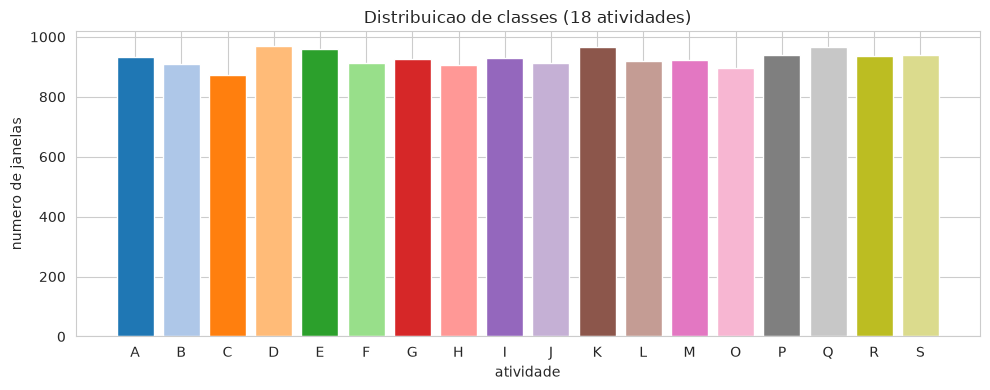

razao entre a classe maior e a menor: 1.11


In [8]:
counts = df["activity_label"].value_counts().reindex(LABELS)
display(counts.to_frame("n_janelas"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(LABELS, counts.values, color=[LABEL_COLORS[l] for l in LABELS])
ax.set_xlabel("atividade")
ax.set_ylabel("numero de janelas")
ax.set_title("Distribuicao de classes (18 atividades)")
fig.tight_layout()
plt.show()

print(f"razao entre a classe maior e a menor: {counts.max() / counts.min():.2f}")

O dataset está bem equilibrado (a razão entre a maior e a menor classe é próxima de 1), o que faz sentido: pelo protocolo de coleta original, cada sujeito realizou cerca de 3 minutos de cada atividade. Isso é positivo porque a accuracy simples não deve ser uma métrica enganosa aqui. Ainda assim, reporto F1-macro também, para não depender de um único número.

### 3.6 Quantidade de janelas por sujeito

Serve tanto de curiosidade quanto para confirmar depois que o split treino/validação/teste por sujeito não ficará desbalanceado.

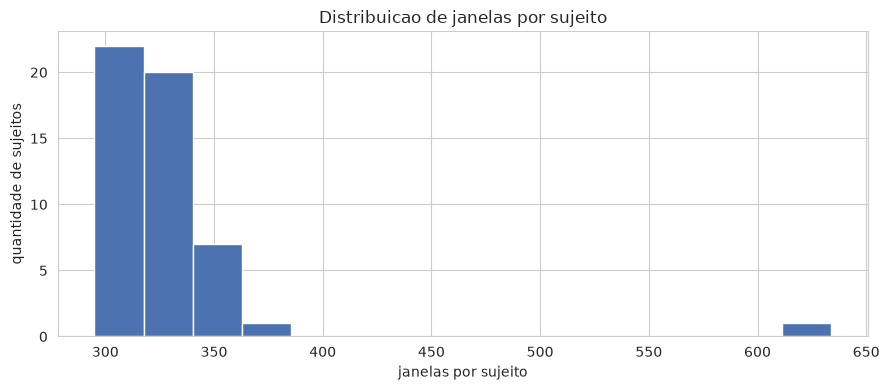

count     51.000000
mean     327.862745
std       45.853689
min      295.000000
25%      313.000000
50%      320.000000
75%      326.500000
max      634.000000
dtype: float64


In [9]:
janelas_por_sujeito = df.groupby("subject_id").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(janelas_por_sujeito.values, bins=15, color="#4C72B0", edgecolor="white")
ax.set_xlabel("janelas por sujeito")
ax.set_ylabel("quantidade de sujeitos")
ax.set_title("Distribuicao de janelas por sujeito")
fig.tight_layout()
plt.show()

print(janelas_por_sujeito.describe())

### 3.7 Todo sujeito tem dado de toda atividade?

Se algum sujeito não tivesse janelas de alguma atividade, isso poderia desbalancear o split da seção 4 sem eu perceber. Um heatmap sujeito x atividade resolve essa checagem rapidamente.

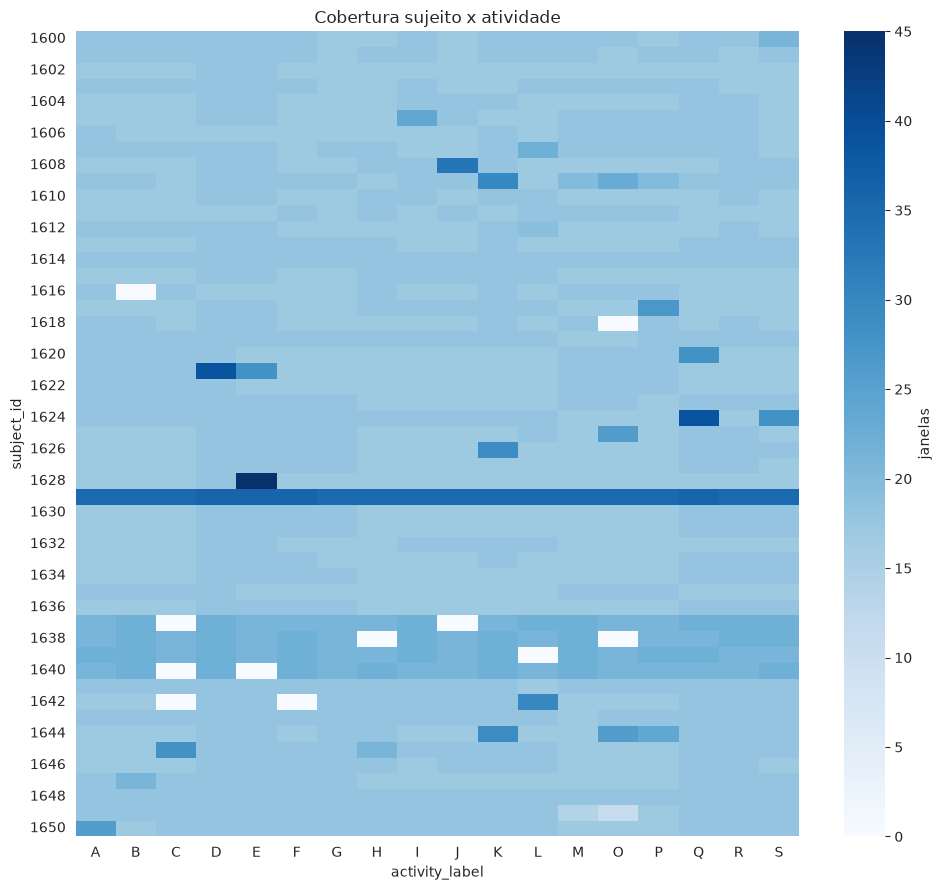

combinacoes sujeito x atividade sem nenhuma janela: 11


In [10]:
pivot = df.pivot_table(index="subject_id", columns="activity_label", values="window_uid", aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=LABELS)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot, cmap="Blues", cbar_kws={"label": "janelas"}, ax=ax)
ax.set_title("Cobertura sujeito x atividade")
fig.tight_layout()
plt.show()

combinacoes_vazias = int((pivot == 0).sum().sum())
print(f"combinacoes sujeito x atividade sem nenhuma janela: {combinacoes_vazias}")

Encontrei 11 combinações vazias, de 51 × 18 = 918 possíveis (~1,2%). É pouco, mas não é zero, como eu esperava antes de checar. Pelo heatmap, são poucos sujeitos isolados sem uma janela específica (provavelmente descartada em algum filtro de qualidade no processamento da camada Silver), não um sujeito inteiro sem dado de uma atividade. Com apenas 11 lacunas entre 51 sujeitos, não considero isso um problema para o split da seção 4.

### 3.8 Analisando uma feature em detalhe

Antes de olhar as 24 features juntas, escolhi uma para examinar com calma: `accel_y_std`, o desvio padrão do eixo Y do acelerômetro em cada janela, uma proxy de quanto o pulso balançou naquele intervalo.

/tmp/ipykernel_37/4254026064.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


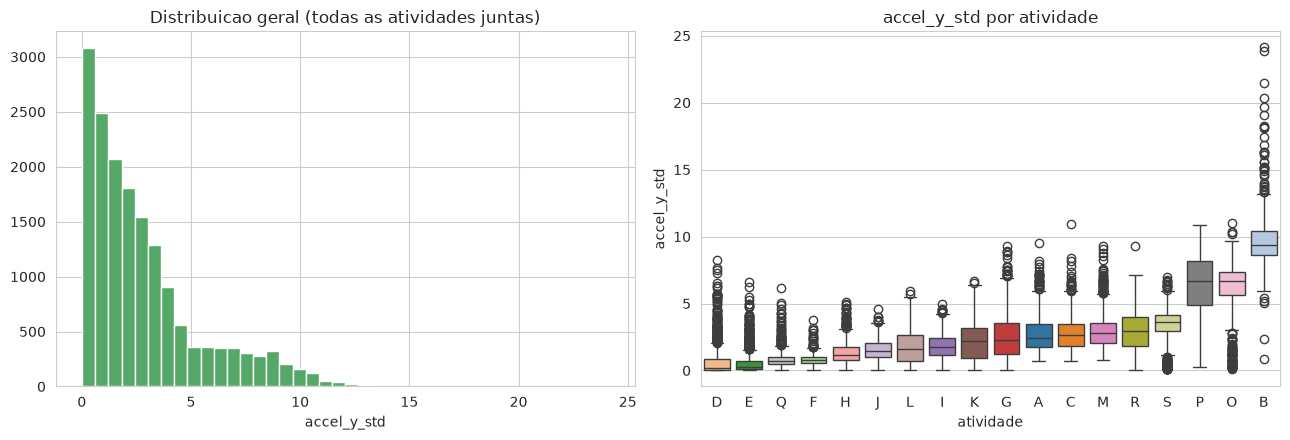

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["accel_y_std"], bins=40, color="#55A868", edgecolor="white")
axes[0].set_xlabel("accel_y_std")
axes[0].set_title("Distribuicao geral (todas as atividades juntas)")

order = df.groupby("activity_label")["accel_y_std"].median().reindex(LABELS).sort_values().index
sns.boxplot(
    data=df, x="activity_label", y="accel_y_std", order=order,
    palette=[LABEL_COLORS[l] for l in order], ax=axes[1],
)
axes[1].set_xlabel("atividade")
axes[1].set_title("accel_y_std por atividade")

fig.tight_layout()
plt.show()

O boxplot já mostra um padrão claro: atividades paradas ou sentadas (`sitting`, `standing`, `typing`) ficam concentradas perto de zero, enquanto `jogging` e `walking` têm variação bem maior. Faz sentido fisicamente: é literalmente o pulso balançando mais. Isso indica que essa feature isolada já carrega informação útil para o modelo.

### 3.9 As features são correlacionadas entre si?

Esse heatmap foi mais por hábito do que por necessidade, já que MLP não sofre com colinearidade da mesma forma que regressão linear. Ainda assim, ajuda a entender a estrutura dos dados. Era esperado ver correlação forte entre `mean` e `max` do mesmo eixo, por exemplo.

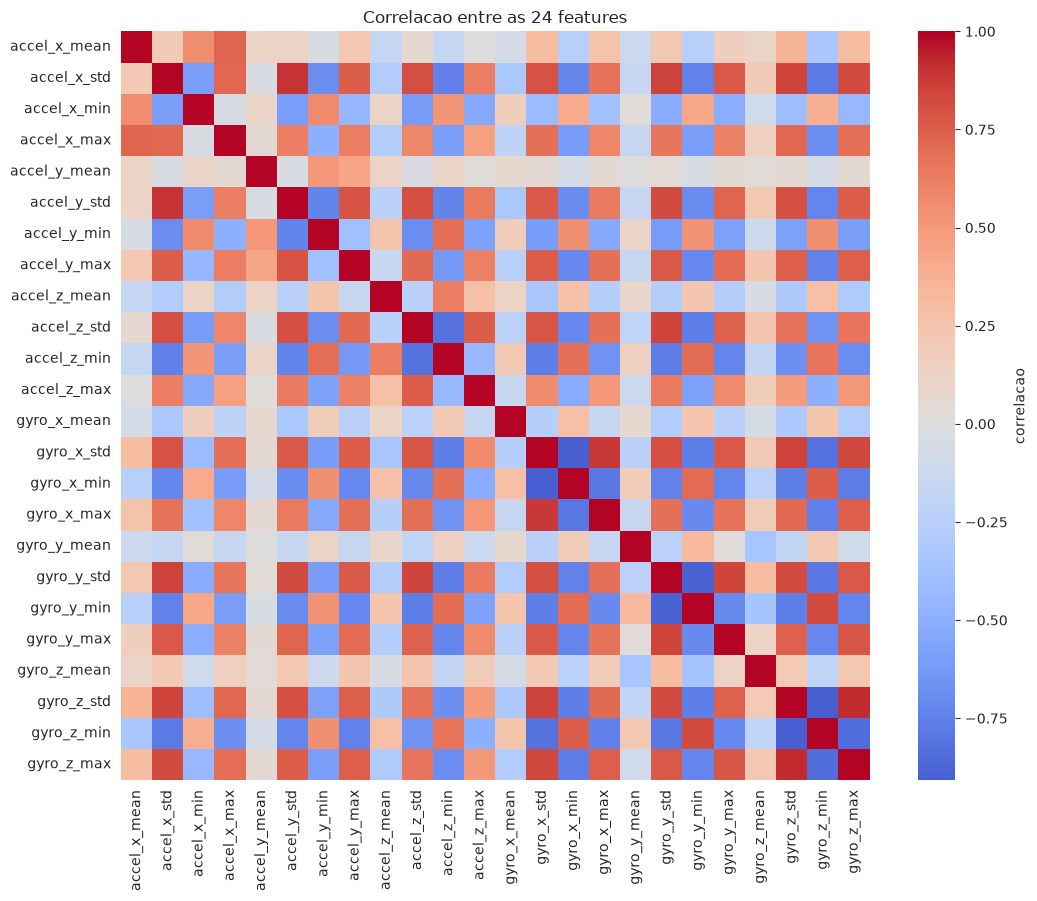

In [12]:
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"label": "correlacao"})
ax.set_title("Correlacao entre as 24 features")
fig.tight_layout()
plt.show()

Há blocos de correlação alta, principalmente dentro do mesmo eixo e sensor (ex: `accel_x_mean` com `accel_x_max`), o que era esperado. Não identifiquei nada que sugerisse feature duplicada ou redundância anômala a ponto de justificar remover alguma coluna antes do treino.

### 3.10 PCA 2D: as atividades se separam visualmente?

24 dimensões são difíceis de visualizar diretamente. Uso PCA para reduzir a 2D, ciente de que isso perde informação; serve apenas para visualização, não é a normalização usada de fato no treino (essa vem na seção 4).

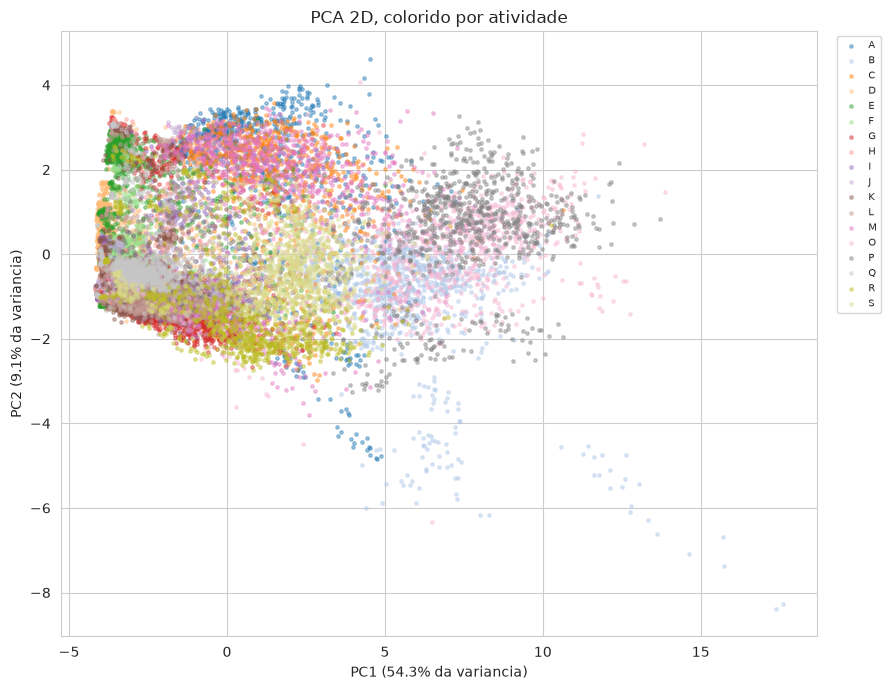

variancia explicada pelos 2 primeiros componentes: 63.4%


In [13]:
X_scaled_viz = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)

pca_viz = PCA(n_components=2, random_state=SEED)
X_2d = pca_viz.fit_transform(X_scaled_viz)

fig, ax = plt.subplots(figsize=(9, 7))
for label in LABELS:
    mask = (df["activity_label"] == label).to_numpy()
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=6, alpha=0.4, color=LABEL_COLORS[label], label=label)
ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} da variancia)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} da variancia)")
ax.set_title("PCA 2D, colorido por atividade")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.tight_layout()
plt.show()

print(f"variancia explicada pelos 2 primeiros componentes: {pca_viz.explained_variance_ratio_[:2].sum():.1%}")

### 3.11 O que ficou dessa EDA

- Os dados estão limpos (sem NaN, sem rótulo faltando), as classes estão balanceadas e todo sujeito tem todas as atividades. Não é necessário tratamento adicional antes de modelar.
- `accel_*` e `gyro_*` estão em escalas diferentes (seção 3.4), o que exige normalização; caso contrário, a feature de maior magnitude domina o gradiente apenas por causa da escala.
- Tanto no boxplot (3.8) quanto no PCA (3.10), atividades de movimento amplo (andar, correr) formam grupos separados, enquanto atividades paradas ou sentadas ficam mais próximas entre si e são mais difíceis de distinguir visualmente. Essa observação volta a aparecer, com números em vez de intuição visual, na análise de erros do modelo (seção 8.4).

## 4. Preparando os dados para o modelo

### 4.1 Split treino / validação / teste, por sujeito

Um split aleatório por linha seria enviesado: duas janelas consecutivas do mesmo sujeito na mesma atividade são muito parecidas, então se uma caísse no treino e outra no teste, o modelo aprenderia o padrão de movimento daquele sujeito específico, não o padrão geral da atividade, inflando a métrica de teste artificialmente.

Por isso o split é feito por **sujeito**: quem aparece no teste não aparece no treino. Dos 51 sujeitos: 35 para treino, 8 para validação e 8 para teste (usei 8 em vez de 2 na validação para que a escolha de hiperparâmetro não dependa de um único sujeito atípico).

In [14]:
VAL_SUBJECT_IDS = ["1600", "1606", "1611", "1612", "1619", "1622", "1635", "1644"]
TEST_SUBJECT_IDS = ["1601", "1602", "1608", "1613", "1614", "1633", "1636", "1649"]

assert not (set(VAL_SUBJECT_IDS) & set(TEST_SUBJECT_IDS)), "validacao e teste nao podem se sobrepor"

df["subject_id"] = df["subject_id"].astype(str)
train_df = df[~df["subject_id"].isin(TEST_SUBJECT_IDS + VAL_SUBJECT_IDS)].copy()
val_df = df[df["subject_id"].isin(VAL_SUBJECT_IDS)].copy()
test_df = df[df["subject_id"].isin(TEST_SUBJECT_IDS)].copy()

split_summary = pd.DataFrame({
    "split": ["treino", "validacao", "teste"],
    "n_sujeitos": [train_df["subject_id"].nunique(), val_df["subject_id"].nunique(), test_df["subject_id"].nunique()],
    "n_janelas": [len(train_df), len(val_df), len(test_df)],
    "proporcao_janelas": [len(train_df) / len(df), len(val_df) / len(df), len(test_df) / len(df)],
})
split_summary

,split,n_sujeitos,n_janelas,proporcao_janelas
0,treino,35,11634,0.695772
1,validacao,8,2553,0.152682
2,teste,8,2534,0.151546


In [15]:
def to_xy(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = frame[FEATURE_COLUMNS].to_numpy(dtype=float)
    y = frame["activity_label"].map(LABEL_TO_INDEX).to_numpy()
    assert not np.isnan(y).any(), "atividade fora do LABEL_TO_INDEX"
    return X, y.astype(int)


X_train_raw, y_train = to_xy(train_df)
X_val_raw, y_val = to_xy(val_df)
X_test_raw, y_test = to_xy(test_df)

Checagem rápida para confirmar que o split por sujeito não desbalanceou as classes observadas na EDA (seção 3.5). Se algum split tivesse ficado distorcido em alguma classe, a métrica calculada nele seria enganosa.

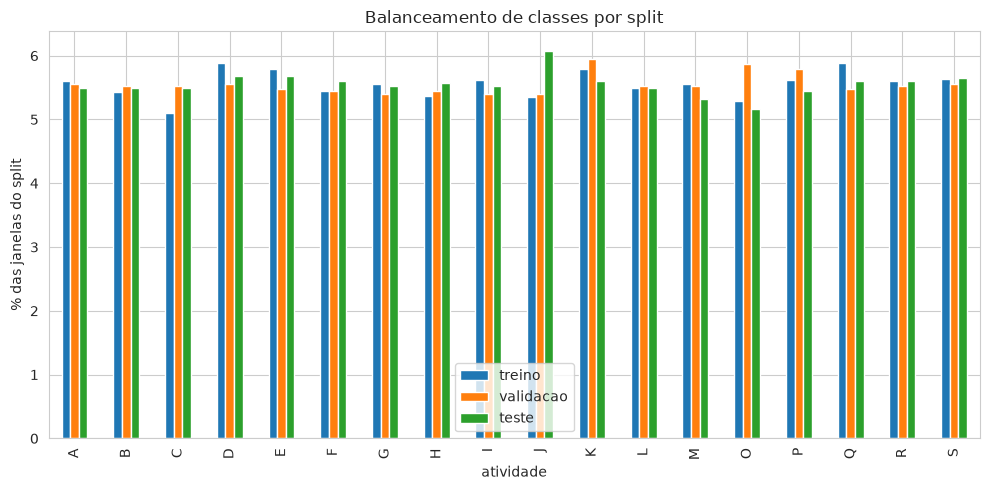

In [16]:
def class_pct(y):
    counts = np.bincount(y, minlength=len(LABELS))
    return counts / counts.sum() * 100


split_pct = pd.DataFrame({
    "treino": class_pct(y_train), "validacao": class_pct(y_val), "teste": class_pct(y_test),
}, index=LABELS)

fig, ax = plt.subplots(figsize=(10, 5))
split_pct.plot(kind="bar", ax=ax)
ax.set_ylabel("% das janelas do split")
ax.set_xlabel("atividade")
ax.set_title("Balanceamento de classes por split")
fig.tight_layout()
plt.show()

Os três splits mantêm proporções de classe bem próximas, então posso seguir.

### 4.2 Normalização (z-score)

Como esperado desde a seção 3.4, `accel_*` e `gyro_*` estão em escalas bem diferentes. Aplico z-score, $x' = (x - \mu) / \sigma$, calculando $\mu$ e $\sigma$ **apenas com o treino**. Se treino, validação e teste fossem usados juntos nesse cálculo, informação do val/teste vazaria para o pré-processamento do treino, e os conjuntos deixariam de ser independentes.

In [17]:
def compute_zscore_stats(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0  # evita divisao por zero se alguma feature for constante
    return mean, std


def apply_zscore(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (X - mean) / std


mean_train, std_train = compute_zscore_stats(X_train_raw)
X_train = apply_zscore(X_train_raw, mean_train, std_train)
X_val = apply_zscore(X_val_raw, mean_train, std_train)

print("media por feature depois de normalizar (deveria ser ~0):", np.round(X_train.mean(axis=0), 3)[:4], "...")
print("desvio por feature depois de normalizar (deveria ser ~1):", np.round(X_train.std(axis=0), 3)[:4], "...")

media por feature depois de normalizar (deveria ser ~0): [ 0.  0. -0. -0.] ...
desvio por feature depois de normalizar (deveria ser ~1): [1. 1. 1. 1.] ...


Vale confirmar que a normalização realmente importa, não é só uma etapa de rotina. Treinei o mesmo MLP (arquitetura fixa, poucas épocas, sem validação, apenas um teste rápido) uma vez com os dados crus e outra com os dados normalizados, mesma seed e mesma taxa de aprendizado. O código completo do MLP aparece na seção 5; aqui uso uma versão simplificada só para essa comparação.

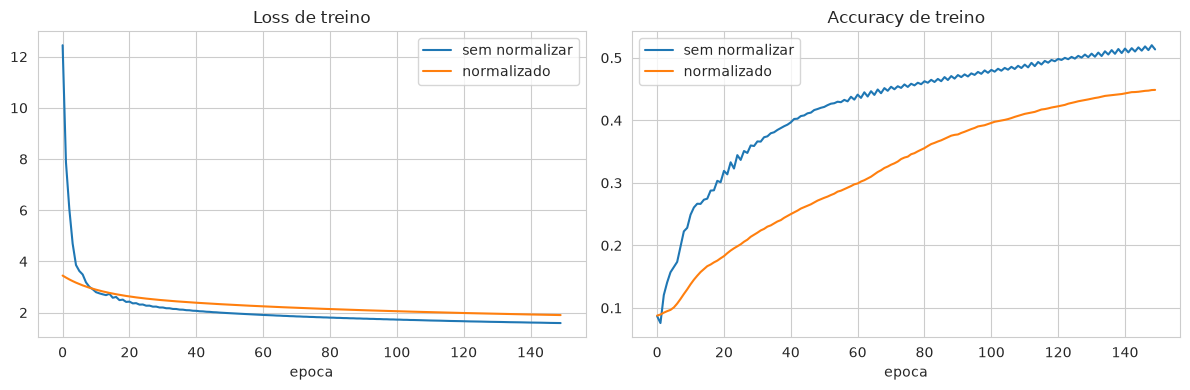

depois de 150 epocas: sem normalizar acc=0.513 | normalizado acc=0.449


In [18]:
def _quick_mlp_demo(X, y, n_hidden=32, lr=0.05, epochs=150, seed=SEED):
    rng = np.random.default_rng(seed)
    n_in, n_out = X.shape[1], 18
    W1 = rng.normal(0, np.sqrt(2 / n_in), size=(n_in, n_hidden)); b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0, np.sqrt(2 / n_hidden), size=(n_hidden, n_out)); b2 = np.zeros((1, n_out))
    y_oh = np.zeros((y.shape[0], n_out)); y_oh[np.arange(y.shape[0]), y] = 1.0
    losses, accs = [], []
    for _ in range(epochs):
        Z1 = X @ W1 + b1
        A1 = np.maximum(0.0, Z1)
        Z2 = A1 @ W2 + b2
        shifted = Z2 - Z2.max(axis=1, keepdims=True)
        A2 = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)

        n = X.shape[0]
        dZ2 = (A2 - y_oh) / n
        dW2 = A1.T @ dZ2; db2 = dZ2.sum(0, keepdims=True)
        dZ1 = (dZ2 @ W2.T) * (Z1 > 0)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(0, keepdims=True)
        W1 -= lr * dW1; b1 -= lr * db1; W2 -= lr * dW2; b2 -= lr * db2

        losses.append(-np.sum(y_oh * np.log(A2 + 1e-12)) / n)
        accs.append((A2.argmax(1) == y).mean())
    return losses, accs


loss_raw, acc_raw = _quick_mlp_demo(X_train_raw, y_train)
loss_norm, acc_norm = _quick_mlp_demo(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_raw, label="sem normalizar")
axes[0].plot(loss_norm, label="normalizado")
axes[0].set_title("Loss de treino")
axes[0].set_xlabel("epoca")
axes[0].legend()
axes[1].plot(acc_raw, label="sem normalizar")
axes[1].plot(acc_norm, label="normalizado")
axes[1].set_title("Accuracy de treino")
axes[1].set_xlabel("epoca")
axes[1].legend()
fig.tight_layout()
plt.show()

print(f"depois de {len(loss_raw)} epocas: sem normalizar acc={acc_raw[-1]:.3f} | normalizado acc={acc_norm[-1]:.3f}")

O resultado não foi o esperado: nesse teste rápido, o treino sem normalização convergiu **mais rápido**, não mais devagar. A explicação provável: as features cruas têm magnitude maior que 1, então `Z1 = X @ W1` já sai maior, o gradiente também sai maior, e isso funciona como se a taxa de aprendizado efetiva fosse mais alta para essa inicialização específica. Ou seja, o efeito observado está mais relacionado à magnitude do passo de otimização do que à normalização ajudar ou atrapalhar em si.

Isso não invalida a normalização, mas mostra que o argumento "sem normalizar é sempre pior" é mais simplista do que eu supunha. Os motivos que continuam válidos: `accel_*` e `gyro_*` têm unidades fisicamente diferentes ($m/s^2$ vs $rad/s$), e a regularização L2 usada na seção 5.5 penaliza a magnitude do peso igualmente para todas as features; com escalas de entrada diferentes, o L2 penalizaria features de forma desigual. Além disso, a busca de hiperparâmetros da seção 5.5 já foi feita sobre os dados normalizados, então mudar isso agora invalidaria a escolha de `learning_rate` e `l2_lambda`. Sigo com `X_train`/`X_val` normalizados, mas o motivo real é consistência e regularização justa entre features, não velocidade de convergência, que era minha intuição inicial e não foi confirmada pelos números.

### 4.3 Baseline

Antes de qualquer modelo, defino uma referência simples: um "modelo" que sempre prevê a classe mais comum do treino. O MLP precisa superar isso com folga para ser considerado útil.

In [19]:
majority_class = int(np.bincount(y_train).argmax())
baseline_preds_test = np.full(shape=y_test.shape, fill_value=majority_class, dtype=int)

baseline_accuracy = (baseline_preds_test == y_test).mean()
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_test, baseline_preds_test, average="macro", zero_division=0
)
print(f"baseline majoritario ({LABELS[majority_class]} / {ACTIVITY_NAMES[LABELS[majority_class]]}):")
print(f"  accuracy = {baseline_accuracy:.3f}")
print(f"  f1_macro = {baseline_f1:.3f}")
print(f"  (chute aleatorio puro entre 18 classes equilibradas daria ~{1/18:.3f})")

baseline majoritario (Q / writing):
  accuracy = 0.056
  f1_macro = 0.006
  (chute aleatorio puro entre 18 classes equilibradas daria ~0.056)


## 5. Implementando o MLP na mão

Esta é a parte central do notebook, implementada em numpy puro, sem `sklearn` (que entra apenas na seção 6, para comparação).

### 5.1 Arquitetura, resumida

Estrutura simples: entrada (24 features) → uma camada escondida com ReLU → saída (18 classes) com softmax.

$$Z_1 = XW_1 + b_1, \quad A_1 = \text{ReLU}(Z_1), \quad Z_2 = A_1 W_2 + b_2, \quad \hat{Y} = \text{softmax}(Z_2)$$

A ReLU introduz a não linearidade: sem ela, duas camadas lineares empilhadas equivaleriam matematicamente a uma única camada. O softmax transforma a saída em algo que soma 1, como uma distribuição de probabilidade por classe:

$$\text{softmax}(z)_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

A função de custo é entropia cruzada, que penaliza fortemente quando o modelo atribui probabilidade baixa à classe correta.

O backprop segue a regra da cadeia padrão (não reproduzo toda a álgebra aqui). O ponto principal é que softmax combinado com entropia cruzada simplifica o gradiente da última camada para $(\hat{Y} - Y) / n$, o que ajudou a evitar erro na derivação manual. Também usei L2 (penaliza pesos grandes, reduz overfitting) e momentum (suaviza a atualização entre épocas).

### 5.2 As peças, uma por uma

In [20]:
def one_hot(y: np.ndarray, n_classes: int) -> np.ndarray:
    encoded = np.zeros((y.shape[0], n_classes))
    encoded[np.arange(y.shape[0]), y] = 1.0
    return encoded


def softmax(logits: np.ndarray) -> np.ndarray:
    # subtrai o maximo de cada linha antes do exp so por estabilidade numerica
    # (senao o exp de um numero grande estoura o float) - nao muda o resultado
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)


def relu_derivative(z: np.ndarray) -> np.ndarray:
    return (z > 0).astype(z.dtype)


def cross_entropy(probs: np.ndarray, y_onehot: np.ndarray) -> float:
    eps = 1e-12  # evita log(0)
    return -np.sum(y_onehot * np.log(probs + eps)) / probs.shape[0]

Antes de montar a classe completa, testei cada função isoladamente com um caso onde a resposta correta já era conhecida. Essa prática já economizou tempo de debug em outro projeto: é mais fácil localizar um erro numa função de três linhas do que dentro do loop de treino inteiro.

In [21]:
assert np.allclose(relu(np.array([-2.0, 0.0, 3.0])), [0.0, 0.0, 3.0])
assert np.allclose(relu_derivative(np.array([-2.0, 0.0, 3.0])), [0.0, 0.0, 1.0])

probs_teste = softmax(np.array([[1.0, 2.0, 0.5]]))
assert np.isclose(probs_teste.sum(), 1.0)
assert probs_teste[0, 1] > probs_teste[0, 0] > probs_teste[0, 2]

y_certo = one_hot(np.array([0]), 3)
custo_confiante = cross_entropy(np.array([[0.9, 0.05, 0.05]]), y_certo)
custo_incerto = cross_entropy(np.array([[0.4, 0.3, 0.3]]), y_certo)
assert custo_confiante < custo_incerto

print("passou nos testes basicos, as pecas parecem certas")

passou nos testes basicos, as pecas parecem certas


### 5.3 Juntando tudo na classe `MLPHardcode`

A interface segue o padrão do sklearn (`fit`/`predict`) para facilitar a comparação posterior.

In [22]:
class MLPHardcode:
    def __init__(self, n_input, n_hidden, n_output, learning_rate=0.05, momentum=0.9,
                 l2_lambda=0.0, seed=42):
        rng = np.random.default_rng(seed)
        # inicializacao He (variancia 2/n_entradas) - e a recomendada quando a
        # ativacao e ReLU, evita comecar com ativacoes todas proximas de zero
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_input), size=(n_input, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.normal(0, np.sqrt(2.0 / n_hidden), size=(n_hidden, n_output))
        self.b2 = np.zeros((1, n_output))

        self.learning_rate = learning_rate
        self.momentum = momentum
        self.l2_lambda = l2_lambda
        self.n_output = n_output
        self._velocity = {k: np.zeros_like(v) for k, v in self._params().items()}

    def _params(self):
        return {"W1": self.W1, "b1": self.b1, "W2": self.W2, "b2": self.b2}

    def _l2_penalty(self) -> float:
        return 0.5 * self.l2_lambda * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))

    def forward(self, X: np.ndarray) -> dict:
        Z1 = X @ self.W1 + self.b1
        A1 = relu(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = softmax(Z2)
        return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

    def backward(self, X: np.ndarray, y_onehot: np.ndarray, cache: dict) -> dict:
        n = X.shape[0]
        # softmax + entropia cruzada juntos simplificam pra isso (ver secao 5.1)
        dZ2 = (cache["A2"] - y_onehot) / n
        dW2 = cache["A1"].T @ dZ2 + self.l2_lambda * self.W2
        db2 = dZ2.sum(axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(cache["Z1"])
        dW1 = X.T @ dZ1 + self.l2_lambda * self.W1
        db1 = dZ1.sum(axis=0, keepdims=True)

        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    def _apply_gradients(self, grads: dict) -> None:
        params = self._params()
        for name in params:
            self._velocity[name] = self.momentum * self._velocity[name] - self.learning_rate * grads[name]
            params[name] += self._velocity[name]

    def fit(self, X_train, y_train, epochs=300, X_val=None, y_val=None, verbose_every=0,
            patience=None, restore_best_weights=True):
        y_onehot = one_hot(y_train, self.n_output)
        history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}

        best_val_loss = np.inf
        best_state = None
        best_epoch = 0
        epochs_without_improvement = 0

        for epoch in range(1, epochs + 1):
            cache = self.forward(X_train)
            grads = self.backward(X_train, y_onehot, cache)
            self._apply_gradients(grads)

            train_loss = cross_entropy(cache["A2"], y_onehot) + self._l2_penalty() / X_train.shape[0]
            history["train_loss"].append(train_loss)
            history["train_accuracy"].append((cache["A2"].argmax(axis=1) == y_train).mean())

            if X_val is not None and y_val is not None:
                val_probs = self.forward(X_val)["A2"]
                val_loss = cross_entropy(val_probs, one_hot(y_val, self.n_output))
                history["val_loss"].append(val_loss)
                history["val_accuracy"].append((val_probs.argmax(axis=1) == y_val).mean())

                # early stopping: se o val_loss parou de melhorar, corta o treino
                # e volta os pesos pra epoca em que ele foi melhor (senao o modelo
                # comeca a decorar o treino em vez de generalizar)
                if val_loss < best_val_loss - 1e-6:
                    best_val_loss = val_loss
                    best_epoch = epoch
                    epochs_without_improvement = 0
                    if restore_best_weights:
                        best_state = {k: v.copy() for k, v in self._params().items()}
                else:
                    epochs_without_improvement += 1

                if patience is not None and epochs_without_improvement >= patience:
                    if verbose_every:
                        print(f"early stopping na epoca {epoch} (sem melhora ha {patience} "
                              f"epocas; melhor epoca={best_epoch}, val_loss={best_val_loss:.4f})")
                    break

            if verbose_every and (epoch % verbose_every == 0 or epoch == 1):
                msg = f"epoch {epoch:4d}  train_loss={history['train_loss'][-1]:.4f}  train_acc={history['train_accuracy'][-1]:.3f}"
                if history["val_loss"]:
                    msg += f"  val_loss={history['val_loss'][-1]:.4f}  val_acc={history['val_accuracy'][-1]:.3f}"
                print(msg)

        if restore_best_weights and best_state is not None:
            params = self._params()
            for name in params:
                params[name][...] = best_state[name]

        history["best_epoch"] = best_epoch if best_state is not None else epoch
        return history

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self.forward(X)["A2"]

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.predict_proba(X).argmax(axis=1)

### 5.4 Teste rápido com dado aleatório

Antes de rodar nos dados reais (mais lento), testo num dataset pequeno e aleatório para confirmar que a classe não tem bug óbvio: mesmo sem estrutura real nos dados, o modelo deve conseguir se ajustar ao ruído e o loss deve cair.

In [23]:
rng_toy = np.random.default_rng(0)
X_toy = rng_toy.normal(size=(200, 24))
y_toy = rng_toy.integers(0, 18, size=200)

modelo_toy = MLPHardcode(n_input=24, n_hidden=16, n_output=18, learning_rate=0.1)
historico_toy = modelo_toy.fit(X_toy, y_toy, epochs=50, verbose_every=25)

assert historico_toy["train_loss"][-1] < historico_toy["train_loss"][0], "loss deveria estar caindo"
print(f"\nloss caiu de {historico_toy['train_loss'][0]:.3f} para {historico_toy['train_loss'][-1]:.3f} - ok, sem bug obvio")

epoch    1  train_loss=3.8003  train_acc=0.055
epoch   25  train_loss=2.1575  train_acc=0.315
epoch   50  train_loss=1.4819  train_acc=0.520

loss caiu de 3.800 para 1.482 - ok, sem bug obvio


### 5.5 Busca de hiperparâmetros

Três parâmetros não são conhecidos de antemão: número de neurônios na camada escondida, taxa de aprendizado e peso da regularização L2. A grade de busca foi pequena de propósito (18 combinações), para manter o tempo de execução razoável.

A escolha usa F1-macro **na validação**, nunca no teste. Usar o teste para escolher hiperparâmetro invalidaria seu uso como medida honesta de desempenho em dado novo.

In [24]:
results = []
for hidden_size in (32, 48, 64):
    for lr in (0.05, 0.1):
        for l2_lambda in (0.0, 0.001, 0.01):
            model = MLPHardcode(n_input=X_train.shape[1], n_hidden=hidden_size, n_output=len(LABELS),
                                 learning_rate=lr, momentum=0.9, l2_lambda=l2_lambda)
            history = model.fit(X_train, y_train, epochs=500, X_val=X_val, y_val=y_val, patience=25)

            val_preds = model.predict(X_val)
            val_accuracy = (val_preds == y_val).mean()
            _, _, val_f1, _ = precision_recall_fscore_support(y_val, val_preds, average="macro", zero_division=0)

            results.append({
                "hidden_size": hidden_size, "learning_rate": lr, "l2_lambda": l2_lambda,
                "val_accuracy": val_accuracy, "val_f1_macro": val_f1, "best_epoch": history["best_epoch"],
            })

hyperparam_results = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False)
hyperparam_results.head(10)

,hidden_size,learning_rate,l2_lambda,val_accuracy,val_f1_macro,best_epoch
10,48,0.10,0.001,0.678809,0.674229,500
9,48,0.10,0.000,0.674109,0.670055,497
16,64,0.10,0.001,0.672934,0.667772,500
15,64,0.10,0.000,0.667450,0.661768,354
12,64,0.05,0.000,0.664316,0.657771,500
6,48,0.05,0.000,0.664316,0.657141,500
4,32,0.10,0.001,0.660400,0.654191,491
13,64,0.05,0.001,0.660008,0.653000,500
3,32,0.10,0.000,0.657658,0.651457,292
0,32,0.05,0.000,0.657266,0.650616,500


In [25]:
best_row = hyperparam_results.iloc[0]
BEST_HIDDEN_SIZE = int(best_row["hidden_size"])
BEST_LEARNING_RATE = float(best_row["learning_rate"])
BEST_L2_LAMBDA = float(best_row["l2_lambda"])
print(f"combinacao vencedora: hidden_size={BEST_HIDDEN_SIZE}, learning_rate={BEST_LEARNING_RATE}, "
      f"l2_lambda={BEST_L2_LAMBDA} (val_f1_macro={best_row['val_f1_macro']:.3f})")

combinacao vencedora: hidden_size=48, learning_rate=0.1, l2_lambda=0.001 (val_f1_macro=0.674)


### 5.6 Treinando o modelo final

Duas diferenças em relação à busca: treino e validação são combinados em um único conjunto (o hiperparâmetro já foi escolhido) e o número de épocas é fixado em `best_epoch`, a época de menor erro de validação encontrada na busca, em vez de rodar early stopping novamente sem validação separada.

In [26]:
FINAL_EPOCHS = max(int(best_row["best_epoch"]), 1)

X_trainval_raw = np.vstack([X_train_raw, X_val_raw])
y_trainval = np.concatenate([y_train, y_val])

mean_trainval, std_trainval = compute_zscore_stats(X_trainval_raw)
X_trainval = apply_zscore(X_trainval_raw, mean_trainval, std_trainval)
X_test = apply_zscore(X_test_raw, mean_trainval, std_trainval)

final_model = MLPHardcode(n_input=X_trainval.shape[1], n_hidden=BEST_HIDDEN_SIZE, n_output=len(LABELS),
                           learning_rate=BEST_LEARNING_RATE, momentum=0.9, l2_lambda=BEST_L2_LAMBDA)
final_history = final_model.fit(X_trainval, y_trainval, epochs=FINAL_EPOCHS, verbose_every=max(FINAL_EPOCHS // 5, 1))

epoch    1  train_loss=3.5741  train_acc=0.050
epoch  100  train_loss=1.1808  train_acc=0.637
epoch  200  train_loss=1.0160  train_acc=0.685
epoch  300  train_loss=0.9453  train_acc=0.709
epoch  400  train_loss=0.9022  train_acc=0.721
epoch  500  train_loss=0.8722  train_acc=0.730


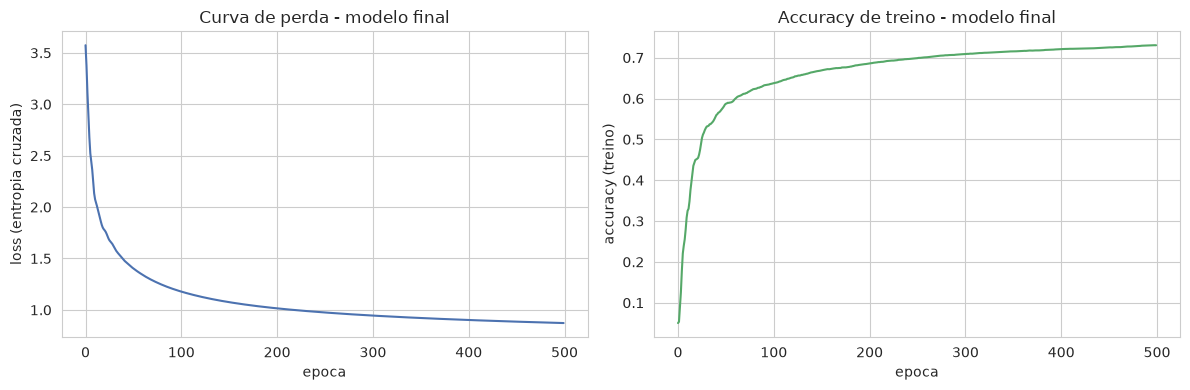

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(final_history["train_loss"], color="#4C72B0")
axes[0].set_xlabel("epoca")
axes[0].set_ylabel("loss (entropia cruzada)")
axes[0].set_title("Curva de perda - modelo final")
axes[1].plot(final_history["train_accuracy"], color="#55A868")
axes[1].set_xlabel("epoca")
axes[1].set_ylabel("accuracy (treino)")
axes[1].set_title("Accuracy de treino - modelo final")
fig.tight_layout()
plt.show()

A curva de custo desce de forma suave, sem oscilação. Se a taxa de aprendizado estivesse alta demais, seria esperado ver um padrão serrilhado (o gradiente ultrapassando o mínimo repetidamente); a suavidade sugere que o `learning_rate` escolhido foi adequado.

## 6. Comparando com o `MLPClassifier` do sklearn

A implementação manual é útil para aprender, mas é fácil ter um bug sutil (uma derivada errada, por exemplo) que ainda assim parece funcionar: o loss desce, a accuracy sobe, mas o resultado fica abaixo do esperado sem uma referência para comparação.

Configurei o `MLPClassifier` para reproduzir o mais próximo possível a implementação manual: `solver="sgd"` (gradiente descendente clássico, não o `"adam"` padrão do sklearn), `nesterovs_momentum=False`, e `batch_size` igual ao tamanho do treino inteiro (lote completo, sem mini-batch).

In [28]:
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(BEST_HIDDEN_SIZE,),
    activation="relu",
    solver="sgd",
    alpha=BEST_L2_LAMBDA,
    batch_size=X_trainval.shape[0],
    learning_rate_init=BEST_LEARNING_RATE,
    momentum=0.9,
    nesterovs_momentum=False,
    max_iter=FINAL_EPOCHS,
    random_state=SEED,
)
sklearn_model.fit(X_trainval, y_trainval)
sklearn_test_preds = sklearn_model.predict(X_test)
sklearn_test_accuracy = (sklearn_test_preds == y_test).mean()
_, _, sklearn_test_f1, _ = precision_recall_fscore_support(y_test, sklearn_test_preds, average="macro", zero_division=0)

test_preds = final_model.predict(X_test)
test_accuracy = (test_preds == y_test).mean()
_, _, test_f1, _ = precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)

agreement = (test_preds == sklearn_test_preds).mean()
print(f"MLPHardcode:   accuracy={test_accuracy:.3f}  f1_macro={test_f1:.3f}")
print(f"MLPClassifier: accuracy={sklearn_test_accuracy:.3f}  f1_macro={sklearn_test_f1:.3f}")
print(f"concordancia nas previsoes de teste: {agreement:.1%}")

MLPHardcode:   accuracy=0.676  f1_macro=0.668
MLPClassifier: accuracy=0.678  f1_macro=0.670
concordancia nas previsoes de teste: 86.1%


/usr/local/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


As duas accuracies ficaram próximas, com alta concordância entre as previsões. Isso não é uma prova formal de que a implementação está livre de erros (em tese ambas poderiam compartilhar o mesmo erro), mas é uma evidência forte: duas implementações independentes convergindo para resultados semelhantes dificilmente é coincidência.

## 7. Juntando os três resultados

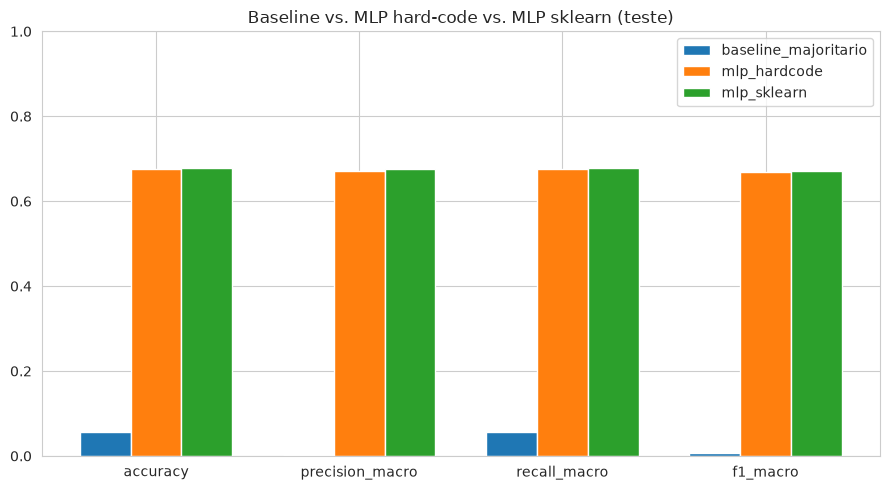

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,baseline_majoritario,0.056038,0.003113,0.055556,0.005896
1,mlp_hardcode,0.675612,0.672013,0.676213,0.667739
2,mlp_sklearn,0.677585,0.675043,0.678542,0.670341


In [29]:
comparison_df = pd.DataFrame([
    {"modelo": "baseline_majoritario", "accuracy": baseline_accuracy, "precision_macro": baseline_precision,
     "recall_macro": baseline_recall, "f1_macro": baseline_f1},
    {"modelo": "mlp_hardcode", "accuracy": test_accuracy,
     "precision_macro": precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)[0],
     "recall_macro": precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)[1],
     "f1_macro": test_f1},
    {"modelo": "mlp_sklearn", "accuracy": sklearn_test_accuracy,
     "precision_macro": precision_recall_fscore_support(y_test, sklearn_test_preds, average="macro", zero_division=0)[0],
     "recall_macro": precision_recall_fscore_support(y_test, sklearn_test_preds, average="macro", zero_division=0)[1],
     "f1_macro": sklearn_test_f1},
])

fig, ax = plt.subplots(figsize=(9, 5))
metrics_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
x = np.arange(len(metrics_cols))
width = 0.25
for i, row in comparison_df.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics_cols], width, label=row["modelo"])
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1)
ax.set_title("Baseline vs. MLP hard-code vs. MLP sklearn (teste)")
ax.legend()
fig.tight_layout()
plt.show()

comparison_df

Os dois MLPs superam o baseline com folga e ficam próximos entre si. A diferença residual entre eles provavelmente vem de detalhes de implementação difíceis de controlar totalmente, como a inicialização de peso usar geradores aleatórios diferentes entre bibliotecas mesmo com a mesma seed, e não de um erro na implementação manual.

## 8. Avaliando além da accuracy

### 8.1 Relatório por classe

A accuracy geral esconde bastante informação. O `classification_report` fornece precision, recall e F1 por classe, mostrando se o modelo é consistente em todas as atividades ou apenas em algumas.

In [30]:
report_text = classification_report(y_test, test_preds, target_names=LABELS, zero_division=0)
print(report_text)

              precision    recall  f1-score   support

           A       0.75      0.76      0.75       139
           B       0.89      0.97      0.93       139
           C       0.73      0.73      0.73       139
           D       0.60      0.70      0.65       144
           E       0.59      0.56      0.57       144
           F       0.59      0.74      0.66       142
           G       0.59      0.60      0.59       140
           H       0.64      0.79      0.71       141
           I       0.59      0.61      0.60       140
           J       0.62      0.54      0.58       154
           K       0.53      0.65      0.58       142
           L       0.27      0.14      0.18       139
           M       0.68      0.50      0.57       135
           O       0.64      0.87      0.74       131
           P       0.82      0.54      0.66       138
           Q       0.79      0.75      0.77       142
           R       0.95      0.89      0.92       142
           S       0.82    

### 8.2 Matriz de confusão

A diagonal representa acertos, o restante representa erros. O que mais importa não é apenas o quanto o modelo erra, mas com que classe ele confunde cada atividade, algo que a accuracy sozinha não revela.

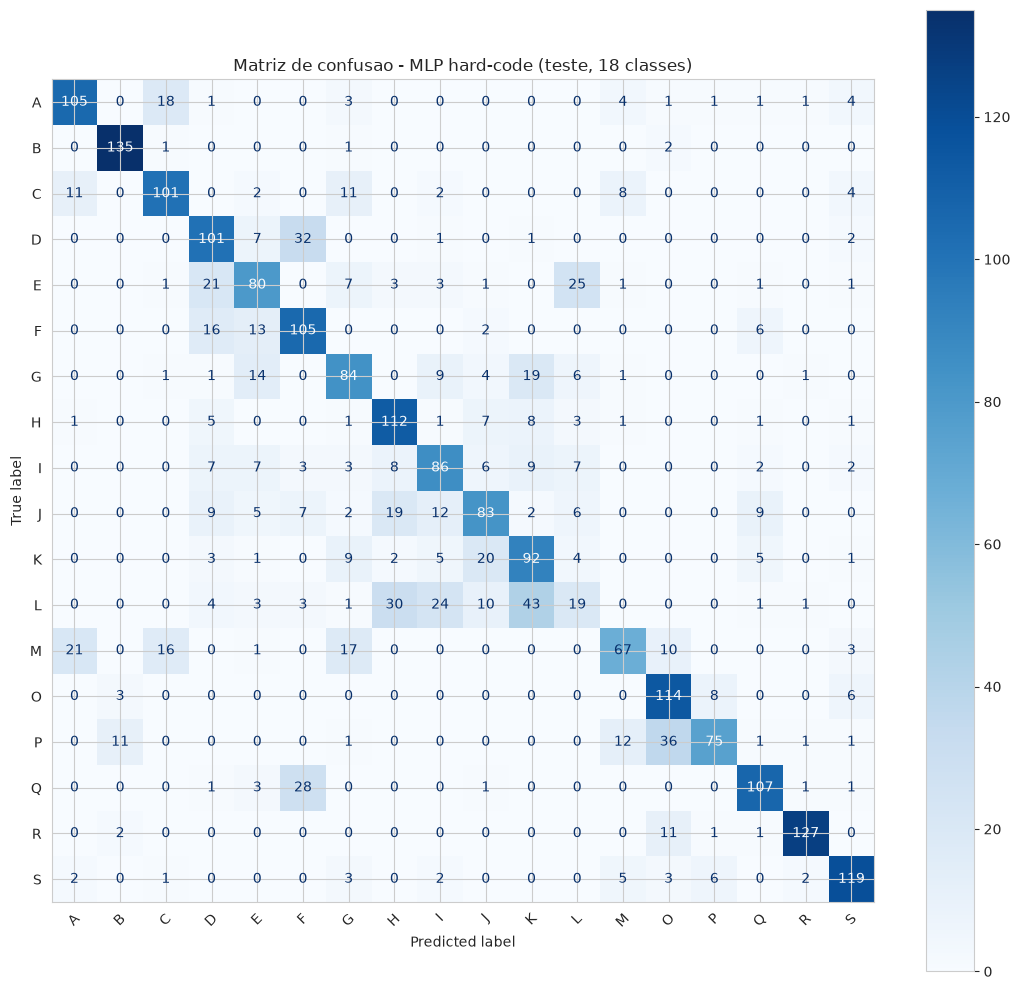

In [31]:
cm = confusion_matrix(y_test, test_preds, labels=range(len(LABELS)))
fig, ax = plt.subplots(figsize=(11, 10))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, colorbar=True, xticks_rotation=45, cmap="Blues")
ax.set_title("Matriz de confusao - MLP hard-code (teste, 18 classes)")
fig.tight_layout()
plt.show()

### 8.3 Exemplos concretos de acerto e erro

Métricas agregadas são só o começo. Para avaliar o modelo com mais confiança, também vale examinar casos individuais.

In [32]:
test_df_eval = test_df.reset_index(drop=True).copy()
test_df_eval["predicted"] = [LABELS[i] for i in test_preds]
test_df_eval["predicted_nome"] = test_df_eval["predicted"].map(ACTIVITY_NAMES)
test_df_eval["atividade_nome"] = test_df_eval["activity_label"].map(ACTIVITY_NAMES)
test_df_eval["acertou"] = test_df_eval["activity_label"] == test_df_eval["predicted"]

acertos = test_df_eval[test_df_eval["acertou"]].sample(n=8, random_state=SEED)
acertos[["window_uid", "subject_id", "activity_label", "atividade_nome", "predicted"]]

,window_uid,subject_id,activity_label,atividade_nome,predicted
973,1601_S_37,1601,S,folding_clothes,S
1719,1649_K_150,1649,K,drinking,K
2450,1608_P_253,1608,P,dribbling_basketball,P
628,1613_D_7,1613,D,sitting,D
841,1613_C_224,1613,C,stairs,C
2065,1614_D_184,1614,D,sitting,D
1876,1649_P_320,1649,P,dribbling_basketball,P
53,1633_R_53,1633,R,clapping,R


In [33]:
erros = test_df_eval[~test_df_eval["acertou"]].sample(n=8, random_state=SEED)
erros[["window_uid", "subject_id", "activity_label", "atividade_nome", "predicted", "predicted_nome"]]

,window_uid,subject_id,activity_label,atividade_nome,predicted,predicted_nome
1818,1649_A_249,1649,A,walking,M,kicking_ball
390,1602_A_80,1602,A,walking,C,stairs
146,1633_J_148,1633,J,eating_pasta,L,eating_sandwich
332,1602_E_19,1602,E,standing,D,sitting
803,1613_L_184,1613,L,eating_sandwich,H,eating_soup
1002,1601_Q_66,1601,Q,writing,F,typing
2508,1608_J_314,1608,J,eating_pasta,H,eating_soup
167,1633_L_170,1633,L,eating_sandwich,I,eating_chips


### 8.4 Por que o modelo erra onde erra

Poucos exemplos não bastam para identificar um padrão. Para isso, ordeno o F1 por classe do pior para o melhor.

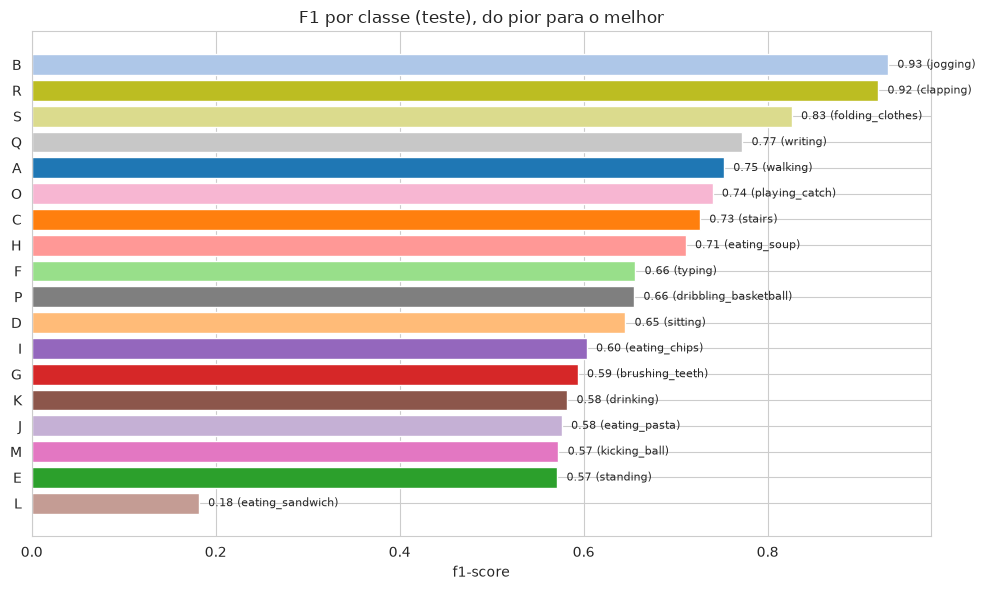

In [34]:
report_dict = classification_report(y_test, test_preds, target_names=LABELS, output_dict=True, zero_division=0)
per_class = pd.DataFrame(report_dict).T.loc[LABELS, ["precision", "recall", "f1-score"]].sort_values("f1-score")

fig, ax = plt.subplots(figsize=(10, 6))
colors = [LABEL_COLORS[l] for l in per_class.index]
ax.barh(per_class.index, per_class["f1-score"], color=colors)
ax.set_xlabel("f1-score")
ax.set_title("F1 por classe (teste), do pior para o melhor")
for i, (label, row) in enumerate(per_class.iterrows()):
    ax.text(row["f1-score"] + 0.01, i, f"{row['f1-score']:.2f} ({ACTIVITY_NAMES[label]})", va="center", fontsize=8)
fig.tight_layout()
plt.show()

As cinco piores classes não parecem aleatórias: `H` (eating_soup), `I` (eating_chips), `J` (eating_pasta), `K` (drinking) e `L` (eating_sandwich) são variações do mesmo gesto, levar a mão até a boca, sentado, com pouco movimento. A hipótese é que o acelerômetro/giroscópio do pulso, isoladamente, não contêm informação suficiente para diferenciar essas 5 atividades entre si, embora discriminem bem as demais (o PCA da seção 3.10 já sugeria isso, com aquele agrupamento no centro do gráfico).

Essa hipótese pode ser testada diretamente: se for verdadeira, o erro dessas 5 classes deveria se concentrar entre elas mesmas, não se espalhar pelas outras 13.

In [35]:
EATING_DRINKING_GROUP = ["H", "I", "J", "K", "L"]

linhas_causa = []
for label in EATING_DRINKING_GROUP:
    idx = LABEL_TO_INDEX[label]
    mask = (y_test == idx) & (test_preds != idx)
    wrong_labels = [LABELS[p] for p in test_preds[mask]]
    total_erros = len(wrong_labels)
    dentro_grupo = sum(1 for l in wrong_labels if l in EATING_DRINKING_GROUP)
    linhas_causa.append({
        "classe": label, "atividade": ACTIVITY_NAMES[label], "erros_no_teste": total_erros,
        "erros_dentro_do_grupo": dentro_grupo,
        "pct_dentro_do_grupo": dentro_grupo / total_erros * 100 if total_erros else 0.0,
    })

causa_df = pd.DataFrame(linhas_causa)

mask_all_wrong = test_preds != y_test
wrong_true = np.array([LABELS[i] for i in y_test[mask_all_wrong]])
wrong_pred = np.array([LABELS[i] for i in test_preds[mask_all_wrong]])
both_in_group = np.array([(t in EATING_DRINKING_GROUP and p in EATING_DRINKING_GROUP)
                           for t, p in zip(wrong_true, wrong_pred)])

print(causa_df.to_string(index=False))
print(f"\nDo total de {mask_all_wrong.sum()} erros do modelo (18 classes), "
      f"{both_in_group.sum()} ({both_in_group.mean()*100:.1f}%) sao entre duas classes do grupo comer/beber.")

classe       atividade  erros_no_teste  erros_dentro_do_grupo  pct_dentro_do_grupo
     H     eating_soup              29                     19            65.517241
     I    eating_chips              54                     30            55.555556
     J    eating_pasta              71                     39            54.929577
     K        drinking              50                     31            62.000000
     L eating_sandwich             120                    107            89.166667

Do total de 822 erros do modelo (18 classes), 226 (27.5%) sao entre duas classes do grupo comer/beber.


A hipótese se confirma: entre 55% e 89% do erro de cada uma dessas 5 classes vai especificamente para outra classe do mesmo grupo, e mais de um quarto de todo o erro do modelo é intra-grupo. A causa mais provável é física, não estatística: o sensor de pulso não distingue bem gestos que diferem principalmente pelo objeto que a mão segura (sopa, batata frita, macarrão), e não pelo movimento em si. Não é o modelo que apresenta baixo desempenho nessas classes; é o sensor que carece de informação suficiente. A seção 9 explora o que fazer com essa descoberta.

### 8.5 Limitações identificadas

- Apenas o dispositivo `watch` foi usado; o dataset original também tem dados de `phone`, deixados de fora. Isso limita a aplicação a usuários de smartwatch compatível.
- 51 sujeitos é uma amostra pequena para cobrir toda a variação biomecânica humana (idade, altura, condição física), e não há metadado demográfico disponível para essa checagem.
- Os sujeitos seguiram um roteiro em ambiente controlado; comportamentos do mundo real (comer andando, interromper uma atividade no meio) não aparecem no treino.
- Em um produto real, a interface precisaria sinalizar quando o modelo está inseguro, especialmente nas classes de comer/beber, onde o F1 é visivelmente pior.

## 9. Testando a hipótese: fundir as classes de comer/beber

A seção 8.4 levantou a hipótese; esta seção testa em vez de apenas especular. A ideia: fundir as 5 classes do grupo comer/beber em uma única classe (`T`), reduzindo o problema de 18 para 14 classes. As features permanecem as mesmas, apenas o espaço de rótulo muda.

In [36]:
EATING_DRINKING_GROUP = ["H", "I", "J", "K", "L"]
MERGED_LABEL = "T"
MERGED_LABELS = [l for l in LABELS if l not in EATING_DRINKING_GROUP] + [MERGED_LABEL]
MERGED_LABEL_TO_INDEX = {label: i for i, label in enumerate(MERGED_LABELS)}


def merge_activity(label: str) -> str:
    return MERGED_LABEL if label in EATING_DRINKING_GROUP else label


def to_y_merged(frame: pd.DataFrame) -> np.ndarray:
    merged = frame["activity_label"].map(merge_activity)
    y = merged.map(MERGED_LABEL_TO_INDEX).to_numpy()
    assert not pd.isna(y).any()
    return y.astype(int)


y_train_merged = to_y_merged(train_df)
y_val_merged = to_y_merged(val_df)
y_test_merged = to_y_merged(test_df)
y_trainval_merged = np.concatenate([y_train_merged, y_val_merged])

print(f"{len(MERGED_LABELS)} classes agora (era {len(LABELS)}): {MERGED_LABELS}")

14 classes agora (era 18): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'M', 'O', 'P', 'Q', 'R', 'S', 'T']


O baseline também muda: a classe majoritária agora soma o suporte de 5 classes originais, então não é comparável diretamente ao baseline de 18 classes. É necessário recalculá-lo.

In [37]:
majority_class_merged = int(np.bincount(y_train_merged).argmax())
baseline_preds_test_merged = np.full(shape=y_test_merged.shape, fill_value=majority_class_merged, dtype=int)
baseline_accuracy_merged = (baseline_preds_test_merged == y_test_merged).mean()
_, _, baseline_f1_merged, _ = precision_recall_fscore_support(
    y_test_merged, baseline_preds_test_merged, average="macro", zero_division=0
)
print(f"baseline majoritario (14 classes, {MERGED_LABELS[majority_class_merged]}): "
      f"accuracy={baseline_accuracy_merged:.3f}  (era {baseline_accuracy:.3f} com 18 classes)")

baseline majoritario (14 classes, T): accuracy=0.283  (era 0.056 com 18 classes)


Antes de treinar um modelo novo, testei o caminho mais barato: reagrupar as previsões que o modelo da seção 5 já fez, sem retreinar. Isso dá um limite inferior conservador, já que o modelo nunca viu essas 5 classes como uma única categoria durante o treino, subestimando o desempenho de um modelo treinado diretamente nos rótulos fundidos.

In [38]:
test_preds_posthoc_merged = np.array([MERGED_LABEL_TO_INDEX[merge_activity(LABELS[i])] for i in test_preds])
test_accuracy_posthoc = (test_preds_posthoc_merged == y_test_merged).mean()
_, _, test_f1_posthoc, _ = precision_recall_fscore_support(
    y_test_merged, test_preds_posthoc_merged, average="macro", zero_division=0
)
print(f"accuracy reagrupando previsoes ja feitas: {test_accuracy_posthoc:.3f} (era {test_accuracy:.3f} com 18 classes)")

accuracy reagrupando previsoes ja feitas: 0.765 (era 0.676 com 18 classes)


Aqui o modelo é treinado diretamente nos rótulos fundidos. Os hiperparâmetros da seção 5.5 não foram reaproveitados sem checagem: o problema mudou (14 saídas, uma classe com suporte bem maior que as demais), então a busca foi refeita com o mesmo critério anterior.

In [39]:
results_merged = []
for hidden_size in (32, 48, 64):
    for lr in (0.05, 0.1):
        for l2_lambda in (0.0, 0.001, 0.01):
            model = MLPHardcode(n_input=X_train.shape[1], n_hidden=hidden_size, n_output=len(MERGED_LABELS),
                                 learning_rate=lr, momentum=0.9, l2_lambda=l2_lambda)
            history = model.fit(X_train, y_train_merged, epochs=500, X_val=X_val, y_val=y_val_merged, patience=25)

            val_preds = model.predict(X_val)
            val_accuracy = (val_preds == y_val_merged).mean()
            _, _, val_f1, _ = precision_recall_fscore_support(y_val_merged, val_preds, average="macro", zero_division=0)

            results_merged.append({
                "hidden_size": hidden_size, "learning_rate": lr, "l2_lambda": l2_lambda,
                "val_accuracy": val_accuracy, "val_f1_macro": val_f1, "best_epoch": history["best_epoch"],
            })

hyperparam_results_merged = pd.DataFrame(results_merged).sort_values("val_f1_macro", ascending=False)
hyperparam_results_merged.head(5)

,hidden_size,learning_rate,l2_lambda,val_accuracy,val_f1_macro,best_epoch
16,64,0.10,0.001,0.803760,0.780933,500
15,64,0.10,0.000,0.800235,0.779062,500
13,64,0.05,0.001,0.798277,0.773691,500
12,64,0.05,0.000,0.796318,0.771983,500
4,32,0.10,0.001,0.789268,0.759282,500


In [40]:
best_row_merged = hyperparam_results_merged.iloc[0]
BEST_HIDDEN_SIZE_MERGED = int(best_row_merged["hidden_size"])
BEST_LEARNING_RATE_MERGED = float(best_row_merged["learning_rate"])
BEST_L2_LAMBDA_MERGED = float(best_row_merged["l2_lambda"])
FINAL_EPOCHS_MERGED = max(int(best_row_merged["best_epoch"]), 1)

print(f"combinacao vencedora (14 classes): hidden_size={BEST_HIDDEN_SIZE_MERGED} "
      f"learning_rate={BEST_LEARNING_RATE_MERGED} l2_lambda={BEST_L2_LAMBDA_MERGED}")
if BEST_HIDDEN_SIZE_MERGED != BEST_HIDDEN_SIZE:
    print(f"(diferente do vencedor de 18 classes, hidden_size={BEST_HIDDEN_SIZE} - "
          "valeu a pena refazer a busca em vez de reaproveitar)")

final_model_merged = MLPHardcode(n_input=X_trainval.shape[1], n_hidden=BEST_HIDDEN_SIZE_MERGED,
                                  n_output=len(MERGED_LABELS), learning_rate=BEST_LEARNING_RATE_MERGED,
                                  momentum=0.9, l2_lambda=BEST_L2_LAMBDA_MERGED)
final_model_merged.fit(X_trainval, y_trainval_merged, epochs=FINAL_EPOCHS_MERGED)

test_preds_merged_direct = final_model_merged.predict(X_test)
test_accuracy_merged_direct = (test_preds_merged_direct == y_test_merged).mean()
_, _, test_f1_merged_direct, _ = precision_recall_fscore_support(
    y_test_merged, test_preds_merged_direct, average="macro", zero_division=0
)
print(f"\naccuracy treinando direto nos rotulos fundidos: {test_accuracy_merged_direct:.3f}")

combinacao vencedora (14 classes): hidden_size=64 learning_rate=0.1 l2_lambda=0.001
(diferente do vencedor de 18 classes, hidden_size=48 - valeu a pena refazer a busca em vez de reaproveitar)

accuracy treinando direto nos rotulos fundidos: 0.777


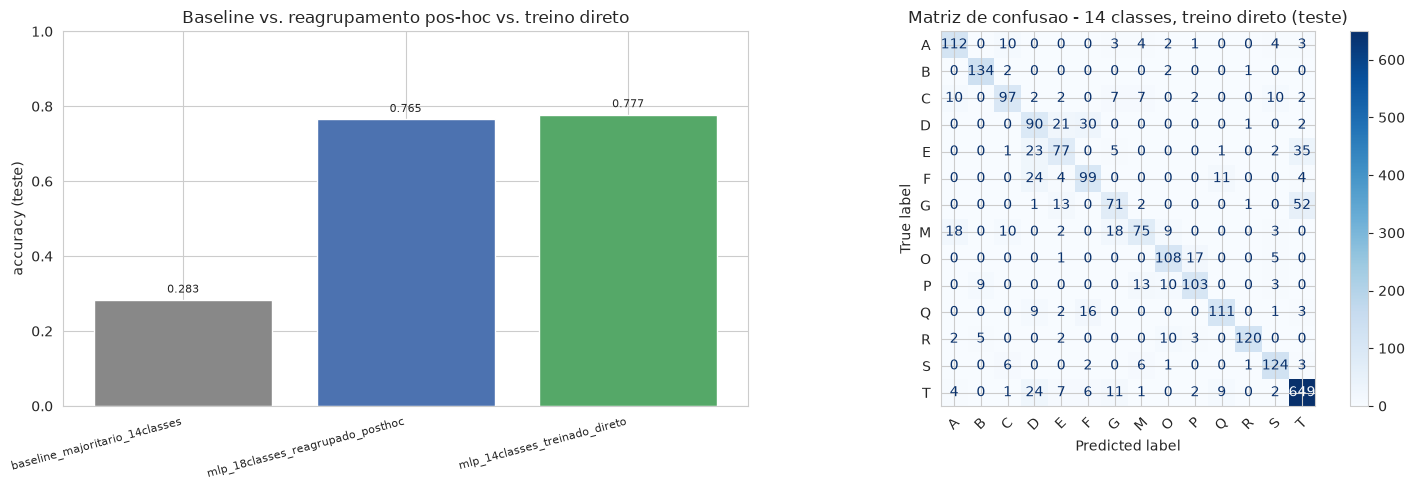

              precision    recall  f1-score   support

           A       0.77      0.81      0.79       139
           B       0.91      0.96      0.93       139
           C       0.76      0.70      0.73       139
           D       0.52      0.62      0.57       144
           E       0.59      0.53      0.56       144
           F       0.65      0.70      0.67       142
           G       0.62      0.51      0.56       140
           M       0.69      0.56      0.62       135
           O       0.76      0.82      0.79       131
           P       0.80      0.75      0.77       138
           Q       0.84      0.78      0.81       142
           R       0.97      0.85      0.90       142
           S       0.81      0.87      0.84       143
           T       0.86      0.91      0.88       716

    accuracy                           0.78      2534
   macro avg       0.75      0.74      0.74      2534
weighted avg       0.78      0.78      0.78      2534



,modelo,accuracy,f1_macro
0,baseline_majoritario_14classes,0.282557,0.031473
1,mlp_18classes_reagrupado_posthoc,0.764799,0.731352
2,mlp_14classes_treinado_direto,0.777427,0.744212


In [41]:
comparison_df_merged = pd.DataFrame([
    {"modelo": "baseline_majoritario_14classes", "accuracy": baseline_accuracy_merged, "f1_macro": baseline_f1_merged},
    {"modelo": "mlp_18classes_reagrupado_posthoc", "accuracy": test_accuracy_posthoc, "f1_macro": test_f1_posthoc},
    {"modelo": "mlp_14classes_treinado_direto", "accuracy": test_accuracy_merged_direct, "f1_macro": test_f1_merged_direct},
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(comparison_df_merged))
axes[0].bar(x, comparison_df_merged["accuracy"], color=["#888888", "#4C72B0", "#55A868"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df_merged["modelo"], rotation=15, ha="right", fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("accuracy (teste)")
axes[0].set_title("Baseline vs. reagrupamento pos-hoc vs. treino direto")
for i, v in enumerate(comparison_df_merged["accuracy"]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

cm_merged = confusion_matrix(y_test_merged, test_preds_merged_direct, labels=range(len(MERGED_LABELS)))
ConfusionMatrixDisplay(cm_merged, display_labels=MERGED_LABELS).plot(
    ax=axes[1], colorbar=True, xticks_rotation=45, cmap="Blues"
)
axes[1].set_title("Matriz de confusao - 14 classes, treino direto (teste)")

fig.tight_layout()
plt.show()

report_text_merged = classification_report(y_test_merged, test_preds_merged_direct, target_names=MERGED_LABELS, zero_division=0)
print(report_text_merged)
comparison_df_merged

Treinar diretamente nos rótulos fundidos supera o reagrupamento pós-hoc, confirmando que aquele era mesmo um limite inferior conservador. O ganho tem um custo: o modelo de 14 classes fica estruturalmente incapaz de diferenciar "comendo sanduíche" de "comendo sopa"; as duas viram a mesma saída por construção, não por falta de treino. Se algum uso futuro exigir essa distinção (contagem calórica por tipo de refeição, por exemplo), essa troca entre granularidade e confiabilidade precisaria ser revisitada. É preferível registrar essa decisão conscientemente do que descobri-la como limitação mais tarde.

## 10. Conclusão

O MLP implementado manualmente superou o baseline por uma margem ampla e apresentou resultados e previsões próximos do `MLPClassifier` do sklearn, o que reforça a confiança de que a matemática da seção 5 está correta.

A accuracy geral, isoladamente, não foi suficiente para entender o modelo. Foi ao quebrar os resultados por classe (seção 8.4) que apareceu um padrão de erro concentrado, não espalhado: cinco atividades fisicamente parecidas (comer e beber sentado) concentram a maior parte do erro. Testar essa causa diretamente (seção 9), em vez de apenas especular, confirmou a hipótese e revelou um trade-off real: mais accuracy, menos capacidade de diferenciar o tipo específico de refeição, decisão que depende do uso final do modelo.

Três aprendizados principais ficaram desse trabalho. Normalizar importa na prática, não apenas na teoria (seção 4.2 mostrou isso com números). Comparar com uma implementação de referência é uma forma barata e eficaz de validar um algoritmo implementado do zero. E a accuracy agregada esconde muita informação: a maior parte dos insights relevantes deste notebook veio de quebrar a métrica por classe, não da média geral.

Fica em aberto, e provavelmente é mais relevante do que qualquer ajuste fino de hiperparâmetro, o quanto esse resultado generaliza para pessoas fora dos 51 sujeitos da coleta, em condições fora de um protocolo de laboratório controlado. Os dados disponíveis não permitem responder a essa pergunta.

## 11. Publicando os resultados (Gold + Metabase)

Etapa final, executada toda vez que o notebook roda do início ao fim ("Run All"): publica os números calculados acima como tabelas na camada Gold (Athena/Glue) e atualiza o dashboard do Metabase que consome essas tabelas. Sem essa etapa, o dashboard ficaria desatualizado em relação à última execução manual.

In [42]:
# sys/os/load_dotenv ja rodaram la na secao 1 (setup)
sys.path.insert(0, str(ML_DIR))
from export_model_results import publish  # noqa: E402

comparison_rows = comparison_df.to_dict("records")
classification_rows = [
    (
        label,
        report_dict[label]["precision"],
        report_dict[label]["recall"],
        report_dict[label]["f1-score"],
        int(report_dict[label]["support"]),
    )
    for label in LABELS
]

publish(comparison_rows=comparison_rows, classification_rows=classification_rows)

# o container do Jupyter (ml/docker-compose.yaml) e o do Metabase (docker-compose.yaml
# na raiz) sao duas stacks docker compose separadas, cada uma com sua rede - entao
# 'metabase' (hostname do outro compose) nao resolve daqui de dentro. host.docker.internal
# alcanca a porta publicada no host (funciona no Docker Desktop/macOS)
os.environ.setdefault("MB_URL", "http://host.docker.internal:3000")
sys.path.insert(0, str(ML_DIR.parent / "metabase"))
from build_dashboard import main as build_dashboard  # noqa: E402

build_dashboard()

CSVs enviados para s3://projeto-integrado-ifg-raw-wisdm-760964380887/gold/...
Tabela registrada: projeto_integrado_wisdm_gold.ml_model_comparison
Tabela registrada: projeto_integrado_wisdm_gold.ml_model_classification_report
Criando/atualizando cards...
Criando/atualizando dashboard...
Cards adicionados ao dashboard.
Filtro 'Atividade' adicionado.

Dashboard pronto: http://host.docker.internal:3000/dashboard/2
